# Analise de Inadimplência - Cartão de Crédito

**Contexto:** 22% dos clientes dessa operadora deixam de pagar a fatura no mês seguinte. Cada calote é prejuízo e a área de cobrança não tem perna para ligar para todo mundo.

**Pergunta de negócio:** Qual perfil de cliente tem maior risco de calote? 

**Por que importa:** Se a cobrança souber *quem* tem mais risco, ela prioriza esses clientes primeiro, recuperando mais dinheiro com menos esforço

**Plano:** Explorar o perfil dos inadimplentes (Python) e entregar um ranking de risco utilizavel pela cobrança (Excel)


 



## Importando a base de dados e pacotes necessários

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
PATH = '../data/default of credit card clients.xls'
df = pd.read_excel(PATH, header=1)


## Primeiras Análises

In [24]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [25]:
df.shape

(30000, 25)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

Nosso dataset não possui valores nulos. 

Uma coisa a ser levada em consideração é que apesar de todas as colunas serem *numéricas* algumas colunas escondem na verdade *categorias*

In [27]:
df['default payment next month'].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

## Primeira análise de negócio

Vamos olhar para o status de pagamento do mês mais recente (coluna PAY_0) onde -1 pagou em dia, 1 atrasou um mês, 2 atrasou 2 mêses... 

Qual **taxa de calote para qual status de pagamento**. Ou seja, dos que estão em dias, quantos % dão calote? E entre os que já atrasaram 2 meses?

In [28]:
df.groupby('PAY_0')['default payment next month'].agg(['mean','count'])

,mean,count
PAY_0,,
-2,0.132294,2759
-1,0.167781,5686
0,0.128113,14737
1,0.339479,3688
2,0.691414,2667
3,0.757764,322
4,0.684211,76
5,0.500000,26
6,0.545455,11


**Grupos de risco:** ao analisar a tabela, vemos que existem grupos que demandam mais atenção, pois são os que possuem a maior proporção de inadimplência. Os grupos são aqueles em que as pessoas atrasam 1,2 meses. Apesar de grupos como o 3 e 7 apresentarem uma proporção alta inadimplentes, são grupos com menor volume de pessoas que 1 e 2 meses de atraso.

In [29]:
g = df.groupby('PAY_0')['default payment next month'].agg(['mean','count'])
g['caloteiros'] = (g['mean'] * g['count']).round().astype(int)
g.sort_values('caloteiros', ascending=False)

,mean,count,caloteiros
PAY_0,,,
0,0.128113,14737,1888
2,0.691414,2667,1844
1,0.339479,3688,1252
-1,0.167781,5686,954
-2,0.132294,2759,365
3,0.757764,322,244
4,0.684211,76,52
5,0.500000,26,13
8,0.578947,19,11


O grupo 0, apesar de ter um numero grande de caloteiros ele possui baixa taxa (~12.8%). Assim não devemos focar nossos esforços nele, uma vez que teriamos que ligar para um grupo de aproximadamente 15mil pessoas pra acertar ~13%. Comparando com o grupo 2 onde temos 69% de inadimplentes onde, com 2667 ligações, a cobrança acerta quase o mesmo número de caloteiros (1844) que acharia ligando para as 15mil do grupo 0. 

**Prioridades** 
- Grupo 2 (atraso de 2 meses) - taxa de 69% em 2667 pessoas. Entrar em contato primeiro, é o mais eficiente com escala.
- Grupo 1 (atraso de 1 mês) - taxa de ~34% em 3688 pessoas: Vale o segundo turno, pois o alcance é alto
- Grupo 0 e negativos - clientes saudáveis; não ligar em massa, maxímo monitora-los

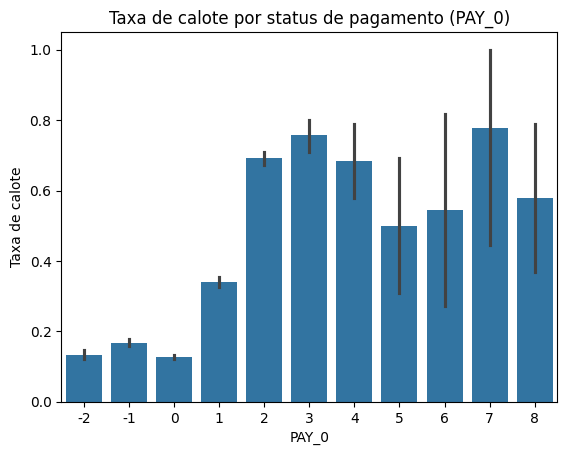

In [30]:
sns.barplot(x=df['PAY_0'], y=df['default payment next month'])
plt.title('Taxa de calote por status de pagamento (PAY_0)')
plt.ylabel('Taxa de calote')
plt.show()

Olhando para o gráfico podemos ver que a barra de erro dos grupos 1 e 2 são significativamente menores que nos grupos de 5 a 8, que são grupos com poucas pessoas. Isso reforça a recomendação anterior, onde ao focar nos grupos 1 e 2 a taxa de acerto é maior e com menos erro, logo temos uma maior eficiência nas chamadas e cobranças

## Agora vamos olhar para o risco por limite de crédito. 

**Hipótese:** Clientes com limite de credito baixo tem menor risco de calote, na outra ponta também existe baixo risco, e o risco real está concentrado em clientes com limite de crédito médio.

In [31]:
bins = [0, 10000, 20000, 50000, 100000, 200000, float('inf')]
labels = ['0-10k', '10k-20k', '20k-50k', '50k-100k', '100k-200k', '200k+']
df['faixa de limite'] = pd.cut(df['LIMIT_BAL'], bins=bins, labels=labels)

In [32]:
df.groupby('faixa de limite')['default payment next month'].agg(['mean','count'])


/tmp/ipykernel_105873/521392322.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa de limite')['default payment next month'].agg(['mean','count'])


,mean,count
faixa de limite,,
0-10k,0.399594,493
10k-20k,0.352882,1978
20k-50k,0.296830,5205
50k-100k,0.257984,4822
100k-200k,0.194797,7880
200k+,0.147267,9622


Os dados mostram que a hipótese é falsa, vemos que o risco de calote cai quanto maior o limite de crédito. 

Clientes que possuem limites baixos, já são clientes com um perfil de risco maior, e logo a operadora de crédito não libera limites altos para eles. Já aqueles com altos limites, são clientes com risco menor, muitas vezes clientes antigos, com bom histórico de pagamento e que já provaram ser bons pagadores.
Isso mostra que existe a correlação entre as variáveis LIMIT_BAL e PAY_0, ou seja, clientes com limite baixo tendem a atrasar mais, e clientes com limite alto tendem a atrasar menos. Porém não me autoriza a usar o limite como alavanca para reduzir o risco de calote, pois não é possível aumentar o limite de crédito de um cliente que já possui um perfil de risco alto.